第一：新建文件

In [47]:
# 导入数据分析所需的工具包
!pip install wordcloud
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from wordcloud import WordCloud

# 设置中文字体，防止图表里的中文变成方块乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

第2：取读数据

In [56]:
# 读取数据文件
sales_df = pd.read_csv('GreenTote_analysis_Chyi_Joelle.csv') 
reviews_df = pd.read_csv('Chyi_Joelle_sentiment.csv')

# 打印数据的前5行
print("GreenTote_analysis_Chyi_Joelle(Sales Data)")
display(sales_df.head())
print("Chyi_Joelle_sentiment(Reviews Data)")
display(reviews_df.head())

GreenTote_analysis_Chyi_Joelle(Sales Data)


,Date,Daily Units Sold,Daily Temperature (C)
0,8/2/2025,420,30
1,8/10/2025,400,30
2,8/11/2025,380,27
3,8/1/2025,380,28
4,8/17/2025,370,28


Chyi_Joelle_sentiment(Reviews Data)


,Review,Rating,sentiment
0,I expected better quality for the price; not w...,1,positive
1,It cleans easily after outdoor adventures; a b...,5,positive
2,Handles are uncomfortable and dig into my hands.,1,negative
3,Lightweight and easy to carry during hikes and...,5,positive
4,The handles are sturdy and comfortable to hold.,5,positive


第3：制作销售业绩与气温图

In [49]:
print (sales_df.columns)

Index(['Date', 'Daily Units Sold', 'Daily Temperature (C)'], dtype='str')


皮尔逊相关系数(Pearson Correlation): 0.8371
P (P-value):0.0000


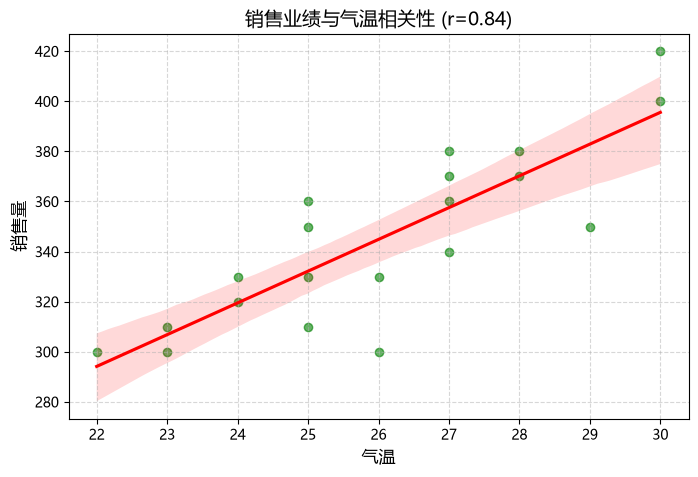

In [50]:
# 填入列名
temp_col = 'Daily Temperature (C)' 
sales_col = 'Daily Units Sold'

# 提取数据
temp_data = sales_df[temp_col]
sales_data = sales_df[sales_col]

# 计算相关系数
corr_coeff, p_value = pearsonr(temp_data, sales_data)
print(f"皮尔逊相关系数(Pearson Correlation): {corr_coeff:.4f}")
print(f"P (P-value):{p_value:.4f}")

# 画图:散点图+回归线
plt.figure(figsize=(8, 5))
sns.regplot(x=temp_col, y=sales_col, data=sales_df, scatter_kws={'alpha':0.6,'color':'green'}, line_kws={'color':'red'})
plt.title(f'销售业绩与气温相关性 (r={corr_coeff:.2f})',fontsize=14)
plt.xlabel('气温',fontsize=12)
plt.ylabel('销售量',fontsize=12)
plt.grid(True, linestyle='--',alpha=0.5)
plt.show()

第4：制作情绪极性数量柱状图

In [51]:
print(reviews_df.columns)

Index(['Review', 'Rating', 'sentiment'], dtype='str')


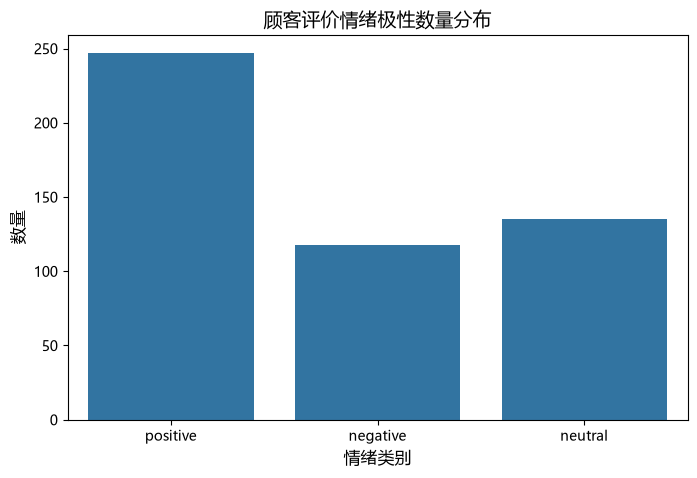

In [52]:
# 作用：统计不同情绪的数量并画柱状图

sentiment_col = 'sentiment'

plt.figure(figsize=(8,5))
# 设定情绪分类值是 Positive, Neutral, Negative
sns.countplot(x=sentiment_col, data=reviews_df)
plt.title('顾客评价情绪极性数量分布',fontsize=14)
plt.xlabel('情绪类别',fontsize=12)
plt.ylabel('数量',fontsize=12)
plt.show()

第5：制作三种情绪的专属词云

In [53]:
print(reviews_df[sentiment_col].unique())

<ArrowStringArray>
['positive', 'negative', 'neutral']
Length: 3, dtype: str


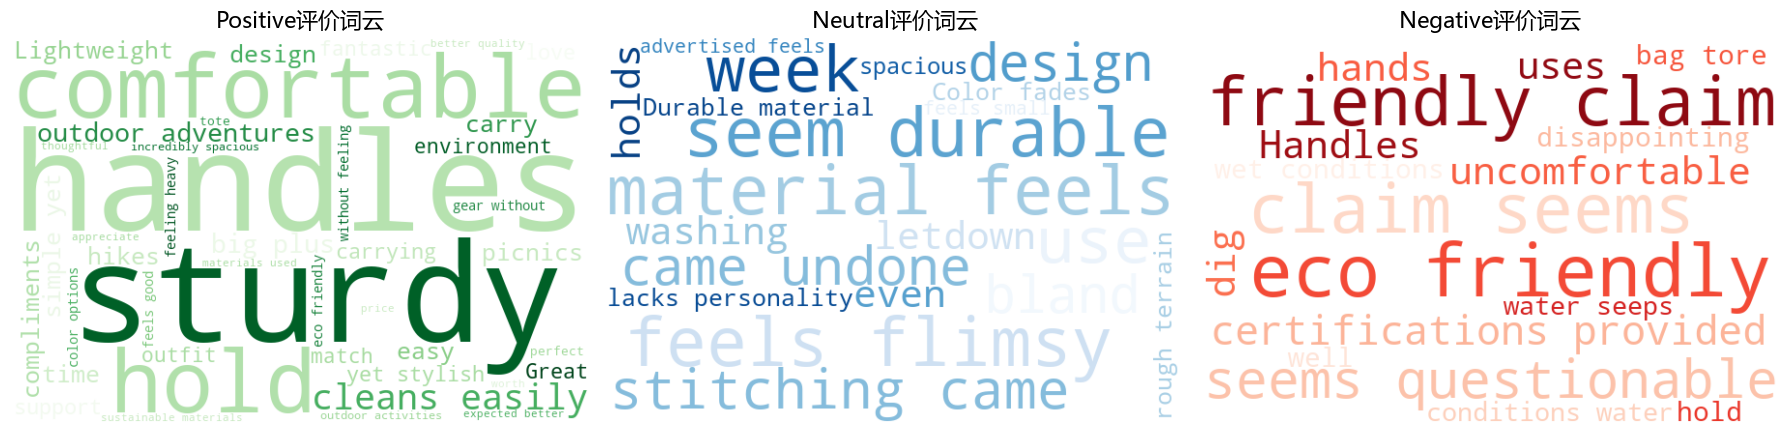

In [54]:
# 分别为正面、中性和负面评价生成词云

text_col = 'Review'
sentiment_col = 'sentiment'

# 定义三种情绪和对应的颜色
sentiments = {'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}

# 画布分为1行3列
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (sentiment, colormap) in enumerate(sentiments.items()):
    # 提取对应情绪的所有文本
    # 过滤出制定情绪的评论，并转成字符串
    filtered_reviews = reviews_df[reviews_df[sentiment_col]==sentiment][text_col]
    # 把评论拼成一个长字符串
    text = " ".join(str(review) for review in filtered_reviews)
    
    # 生成词云
    wordcloud = WordCloud(width=600, height=400, background_color='white', 
                          colormap=colormap,max_words=100).generate(text)
    
    # 画到对应的格子上
    axes[i].imshow(wordcloud, interpolation='bilinear')
    # 设置标题
    axes[i].set_title(f'{sentiment.title()}评价词云',fontsize=16)
    axes[i].axis('off') # 隐藏坐标轴

plt.tight_layout()
plt.show()

第6：制作情绪百分比饼图

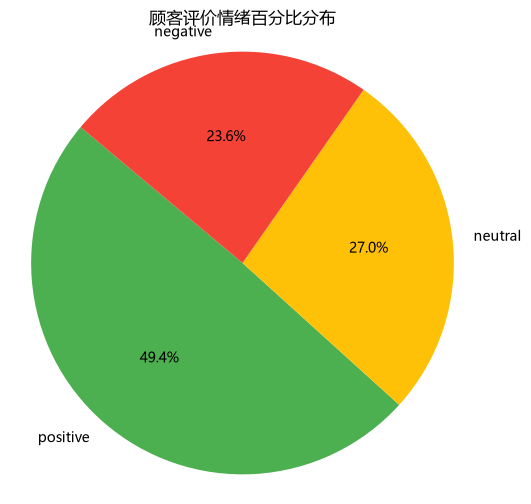

In [57]:
# 作用：展示正面、中性和负面评价的百分比
sentiment_pct = reviews_df['sentiment'].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 6))
# 颜色设置：绿、黄、红
colors = ['#4CAF50', '#FFC107', '#F44336']
plt.pie(sentiment_pct, labels=sentiment_pct.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('顾客评价情绪百分比分布')
plt.axis('equal') # 保证饼图是正圆
plt.show()